In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.colors import LogNorm

OUTROOT = "/work/hdd/bdne/nchartier/Q_correction"
NREAL = 50
N_ITER = 3
figroot = "Figures"
os.makedirs(figroot, exist_ok=True)

# After Q-corrections

In [4]:
def load_pk_ratio_panel(sim, which):
    '''which: "pm", or "it1"/"it2"/"it3" for the corrected iterations.
    Returns a list of (k, ratio) tuples, one per seed, with ratio = P(k)/P_target(k)
    interpolated onto this field's own k-grid.'''
    results = []
    for seed in range(NREAL):
        d = os.path.join(OUTROOT, sim, "seed%d" % seed)
        k_nb = np.load(os.path.join(d, "k_nb.npy"))
        pk_nb = np.load(os.path.join(d, "pk_nb.npy"))

        if which == "pm":
            k_x = np.load(os.path.join(d, "k_pm.npy"))
            pk_x = np.load(os.path.join(d, "pk_pm.npy"))
        else:
            n = int(which.replace("it", ""))
            k_x = np.load(os.path.join(d, "k_corrected_it%d.npy" % n))
            pk_x = np.load(os.path.join(d, "pk_corrected_it%d.npy" % n))

        pk_nb_i = np.interp(k_x, k_nb, pk_nb)
        results.append((k_x, pk_x / pk_nb_i))
    return results


In [5]:
QUIJOTE_ROOT = "/work/hdd/bdne/nchartier/quijote_lh"

def load_saved_field(sim, seed, which, grid):
    '''which: "nb", "pm", or "it1"/"it2"/"it3".
    "nb" (Quijote target) now lives under quijote_lh/{seed}/, not
    Q_correction/{sim}/seed{seed}/ -- moved there by compute_quijote_products.py.'''
    if which == "nb":
        return np.load(os.path.join(QUIJOTE_ROOT, str(seed), "delta_grid%d.npy" % grid))
    d = os.path.join(CORR_ROOT, sim, "seed%d" % seed)
    return np.load(os.path.join(d, "delta_%s_grid%d.npy" % (which, grid)))


def load_pk_ratio_panel(sim, which):
    results = []
    for seed in range(NREAL):
        d = os.path.join(OUTROOT, sim, "seed%d" % seed)
        k_nb = np.load(os.path.join(QUIJOTE_ROOT, str(seed), "k.npy"))
        pk_nb = np.load(os.path.join(QUIJOTE_ROOT, str(seed), "pk.npy"))

        if which == "pm":
            k_x = np.load(os.path.join(d, "k_pm.npy"))
            pk_x = np.load(os.path.join(d, "pk_pm.npy"))
        else:
            n = int(which.replace("it", ""))
            k_x = np.load(os.path.join(d, "k_corrected_it%d.npy" % n))
            pk_x = np.load(os.path.join(d, "pk_corrected_it%d.npy" % n))

        pk_nb_i = np.interp(k_x, k_nb, pk_nb)
        results.append((k_x, pk_x / pk_nb_i))
    return results


def load_quijote_delta(seed, grid):
    '''Every seed (0-100+) now lives under this same convention, so the old
    seed<=49-vs->49 branching is gone -- that split only existed because 0-49
    used to be split across two different locations.'''
    return np.load(os.path.join(QUIJOTE_ROOT, str(seed), "delta_grid%d.npy" % grid))

def plot_pk_ratio_grid(sim, outfile=None):
    fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharex=True, sharey=True,
                              constrained_layout=True)
    cmap = cm.inferno
    norm = Normalize(vmin=0, vmax=NREAL - 1)

    panels = [
        (axes[0, 0], "pm", "PM / target"),
        (axes[0, 1], "it1", "Corrected (1 iteration) / target"),
        (axes[1, 0], "it2", "Corrected (2 iterations) / target"),
        (axes[1, 1], "it3", "Corrected (3 iterations) / target"),
    ]

    for ax, which, title in panels:
        data = load_pk_ratio_panel(sim, which)
        for seed, (k, ratio) in enumerate(data):
            ax.plot(k, ratio, color=cmap(norm(seed)), lw=1)
        ax.axhline(1.0, color="black", lw=2, ls=":")
        ax.set_xscale("log")
        ax.set_title(title, fontsize=13)
        ax.grid(alpha=0.5, color = "grey")

    fts = 15
    axes[1, 0].set_xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$", fontsize=fts)
    axes[1, 1].set_xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$", fontsize=fts)
    axes[0, 0].set_ylabel(r"$P(k)/P_{\rm target}(k)$", fontsize=fts)
    axes[1, 0].set_ylabel(r"$P(k)/P_{\rm target}(k)$", fontsize=fts)

    for ax in axes.flatten():
        ax.tick_params(labelsize = 14)

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, fraction=0.046, pad=0.02, aspect=40)
    cbar.set_label("Seed", fontsize=fts)

    fig.suptitle(sim.upper() + " Q corrections", fontsize=18, weight = "semibold")

    if outfile is not None:
        plt.savefig(outfile, bbox_inches="tight")
    return fig, axes

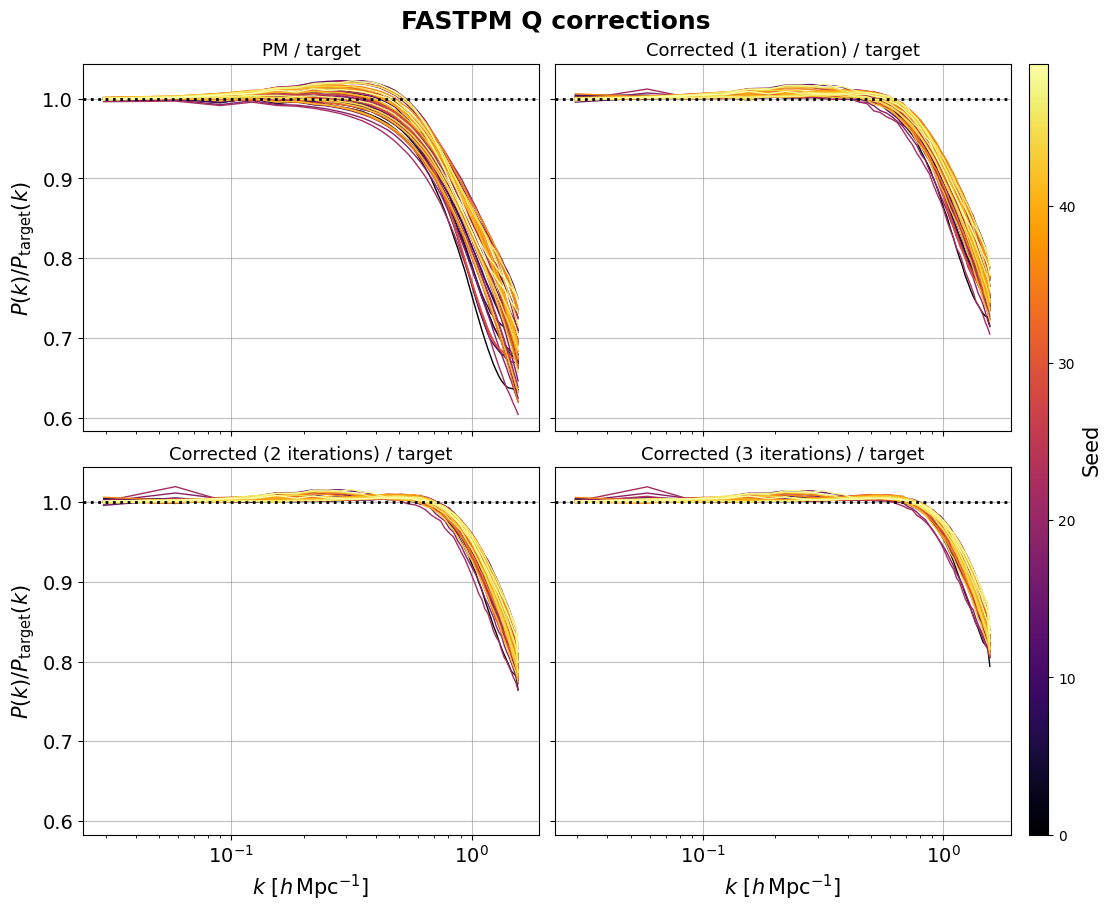

In [6]:
fig, axes = plot_pk_ratio_grid("fastpm", outfile=os.path.join(figroot, "pk_Q_ratio_grid_fastpm.pdf"))


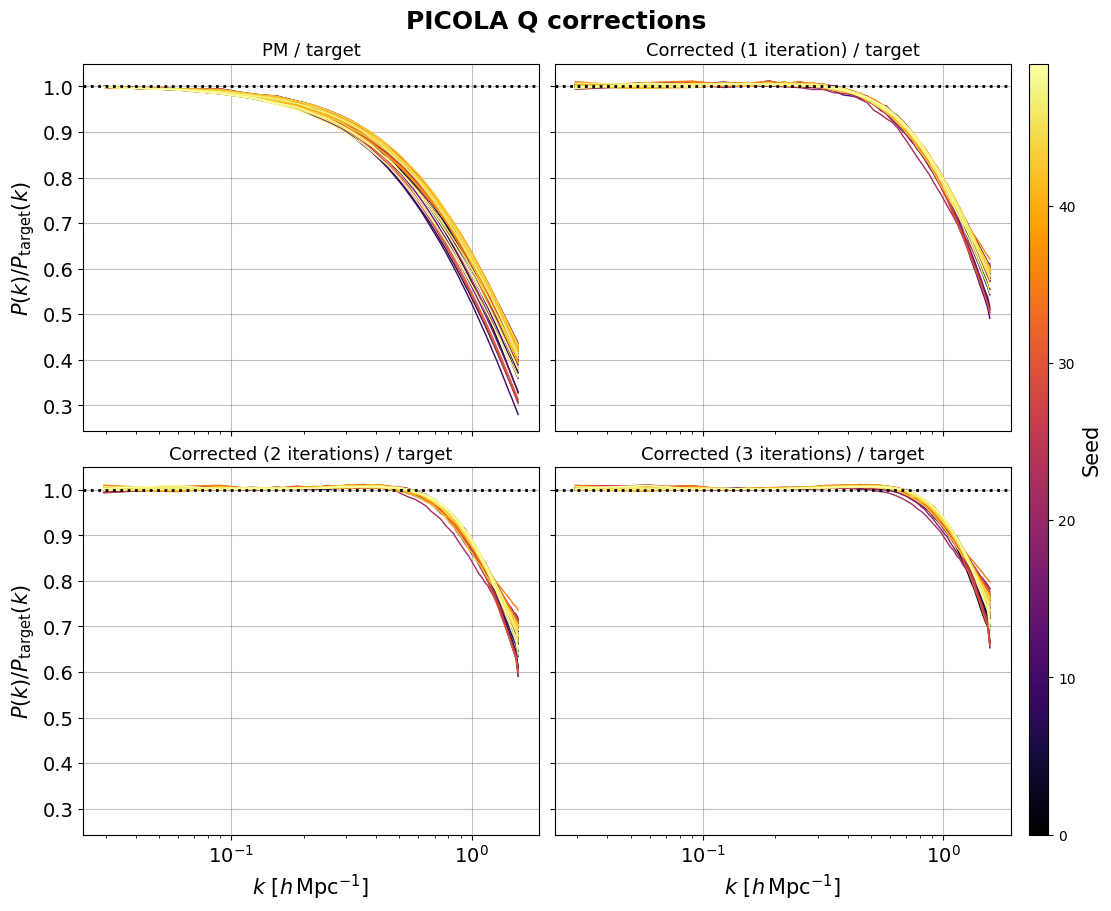

In [7]:
fig, axes = plot_pk_ratio_grid("picola", outfile=os.path.join(figroot, "pk_Q_ratio_grid_picola.pdf"))


In [8]:
CORR_ROOT = "/work/hdd/bdne/nchartier/Q_correction"

def get_boxsize(seed):
    #path = "/work/hdd/bdne/nchartier/quijote_lh/%d/snap_003" % seed
    #header = readgadget.header(path)
    #return header.boxsize / 1e3
    return 1000.


def load_saved_field(sim, seed, which, grid):
    '''which: "nb", "pm", or "it1"/"it2"/"it3"'''
    d = os.path.join(CORR_ROOT, sim, "seed%d" % seed)
    if which in ("nb", "pm"):
        fname = "delta_%s_grid%d.npy" % (which, grid)
    else:
        n = int(which.replace("it", ""))
        fname = "delta_corrected_it%d_grid%d.npy" % (n, grid)
    return np.load(os.path.join(d, fname))


def slice_2d(delta_3d, BoxSize, grid, x_min, x_max, y_min, y_max, z_min, z_max):
    '''z-averaged 2D (1+delta) slice out of a saved 3D delta grid.'''
    cell = BoxSize / grid
    ix_min, ix_max = int(round(x_min / cell)), int(round(x_max / cell))
    iy_min, iy_max = int(round(y_min / cell)), int(round(y_max / cell))
    iz_min, iz_max = int(round(z_min / cell)), int(round(z_max / cell))
    iz_max = max(iz_max, iz_min + 1)
    sub = delta_3d[ix_min:ix_max, iy_min:iy_max, iz_min:iz_max]
    return 1.0 + sub.mean(axis=2)


In [9]:
def plot_fields_slices(fields, labels, x_min, x_max, y_min, y_max, z_min, z_max,
                        scale='log', colmap='hot', dmin=0.1, dmax=100,
                        smooth_sigma=None, figroot=None, fname='dfield_slices.pdf',
                        log_transform=False):
    '''If log_transform=True, plot log10(2+delta) = log10(1+field) on a linear
    color scale instead of the raw (1+delta) field on a log color scale
    (the dmin/dmax clip still applies in the original 1+delta units, before
    the transform, so contrast control behaves the same either way).'''
    from scipy.ndimage import gaussian_filter

    n = len(fields)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 5.5),
                              sharey=True, constrained_layout=True)
    if n == 1:
        axes = [axes]

    fields = [np.clip(gaussian_filter(f, sigma=smooth_sigma) if smooth_sigma is not None else f,
                       dmin, dmax) for f in fields]

    if log_transform:
        fields = [np.log10(1.0 + f) for f in fields]  # log10(2+delta) = log10(1+(1+delta))
        norm = plt.Normalize(vmin=min(f.min() for f in fields), vmax=max(f.max() for f in fields))
    else:
        vmin = min(f.min() for f in fields)
        vmax = max(f.max() for f in fields)
        norm = LogNorm(vmin=vmin, vmax=vmax) if scale == 'log' else plt.Normalize(vmin=vmin, vmax=vmax)

    extent = [x_min, x_max, y_min, y_max]
    im = None
    for ax, field, label in zip(axes, fields, labels):
        im = ax.imshow(field.T, origin='lower', extent=extent,
                        cmap=colmap, norm=norm,
                        interpolation='sinc', aspect='equal')
        ax.set_title(label, fontsize=14)
        ax.set_xlabel(r'$x\ [h^{-1}\mathrm{Mpc}]$', fontsize=14)
    axes[0].set_ylabel(r'$y\ [h^{-1}\mathrm{Mpc}]$', fontsize=14)

    cbar = fig.colorbar(im, ax=axes, fraction=0.05, pad=0.02, aspect=30)
    cbar.set_label(r'$\log_{10}(2+\delta)$' if log_transform else r'$1+\delta$', fontsize=14)
    cbar.ax.tick_params(labelsize=12)
    fig.suptitle(r'$z \in [%.1f,\,%.1f]\ h^{-1}\mathrm{Mpc}$' % (z_min, z_max),
                  fontsize=16)

    if figroot is not None:
        os.makedirs(figroot, exist_ok=True)
        plt.savefig(os.path.join(figroot, fname), bbox_inches="tight")
    return fig, axes

def plot_density_slices(pos_list, labels, BoxSize, grid,
                         x_min, x_max, y_min, y_max, z_min, z_max,
                         scale='log', colmap='hot', dmin=0.1, dmax=100,
                         smooth_sigma=None, figroot=None,
                         fname='dfield_slices.pdf'):
    '''Original position-based version, now just a thin wrapper.'''
    fields = [compute_density_slice_2d(pos, BoxSize, grid,
                                        x_min, x_max, y_min, y_max, z_min, z_max)
              for pos in pos_list]
    return plot_fields_slices(fields, labels, x_min, x_max, y_min, y_max, z_min, z_max,
                               scale=scale, colmap=colmap, dmin=dmin, dmax=dmax,
                               smooth_sigma=smooth_sigma, figroot=figroot, fname=fname)



In [10]:
import readgadget
import bigfile

def load_quijote(seed):
    path = "/work/hdd/bdne/nchartier/quijote_lh/%d/snap_003" % seed
    header = readgadget.header(path)
    BoxSize = header.boxsize / 1e3
    pos = readgadget.read_block(path, "POS ", [1]) / 1e3
    return pos, BoxSize

def load_fastpm(seed):
    path = "/work/hdd/bdne/maho3/cmass-ili/quijotelike_for_nicolas/fastpm/L1000-N128/%d/fastpm_B2_0.6667" % seed
    infile = bigfile.File(path)
    return infile['1/Position'][:]

def load_lpicola(seed):
    path = "/work/hdd/bdne/nchartier/cola_lh/%d/Cola%d_512_20stepsnLPTpos0p5_z0p500" % (seed, seed)
    return readgadget.read_block(path, "POS ", [1]) / 1e3


In [12]:
QUIJOTE_ROOT = "/work/hdd/bdne/nchartier/quijote_lh"

def load_quijote_delta(seed, grid):
    return np.load(os.path.join(QUIJOTE_ROOT, str(seed), "delta_grid%d.npy" % grid))


def load_saved_field(sim, seed, which, grid):
    if which == "nb":
        d = "/work/hdd/bdne/nchartier/quijote_lh/%d" % seed
        fname = "delta_grid%d.npy" % grid
    else:
        d = "/work/hdd/bdne/nchartier/Q_correction/%s/seed%d" % (sim, seed)
        if which == "pm":
            fname = "delta_pm_grid%d.npy" % grid
        else:
            fname = "delta_corrected_%s_grid%d.npy" % (which, grid)
    return np.load(os.path.join(d, fname))


def plot_stage_comparison(seed, stage, grid=512,
                           x_min=0., x_max=600., y_min=0., y_max=600.,
                           z_min=490., z_max=510.,
                           dmin=0.9, dmax=80, smooth_sigma=1.0,
                           figroot=figroot, log_transform=False):
    if stage not in (0, 1, 2, 3):
        raise ValueError("stage must be 0, 1, 2, or 3, got %r" % stage)

    which = "pm" if stage == 0 else "it%d" % stage
    stage_label = "initial" if stage == 0 else "%d Q correction%s" % (stage, "s" if stage > 1 else "")

    BoxSize = get_boxsize(seed)

    field_nb = load_quijote_delta(seed, grid)
    field_picola = load_saved_field("picola", seed, which, grid)
    field_fastpm = load_saved_field("fastpm", seed, which, grid)

    fields_2d = [slice_2d(f, BoxSize, grid, x_min, x_max, y_min, y_max, z_min, z_max)
                 for f in (field_nb, field_picola, field_fastpm)]

    fig, axes = plot_fields_slices(
        fields_2d,
        ["Quijote (target)", "L-PICOLA (%s)" % stage_label, "FastPM (%s)" % stage_label],
        x_min, x_max, y_min, y_max, z_min, z_max,
        scale='log', colmap='hot', dmin=dmin, dmax=dmax,
        smooth_sigma=smooth_sigma, figroot=None, log_transform=log_transform)

    fig.suptitle(r'seed %d, %s ($z \in [%.1f,\,%.1f]\ h^{-1}\mathrm{Mpc}$)' %
                 (seed, stage_label, z_min, z_max), fontsize=16)

    if figroot is not None:
        os.makedirs(figroot, exist_ok=True)
        fname = "dfield_slices_seed%d_stage%d.pdf" % (seed, stage)
        plt.savefig(os.path.join(figroot, fname), bbox_inches="tight")

    return fig, axes


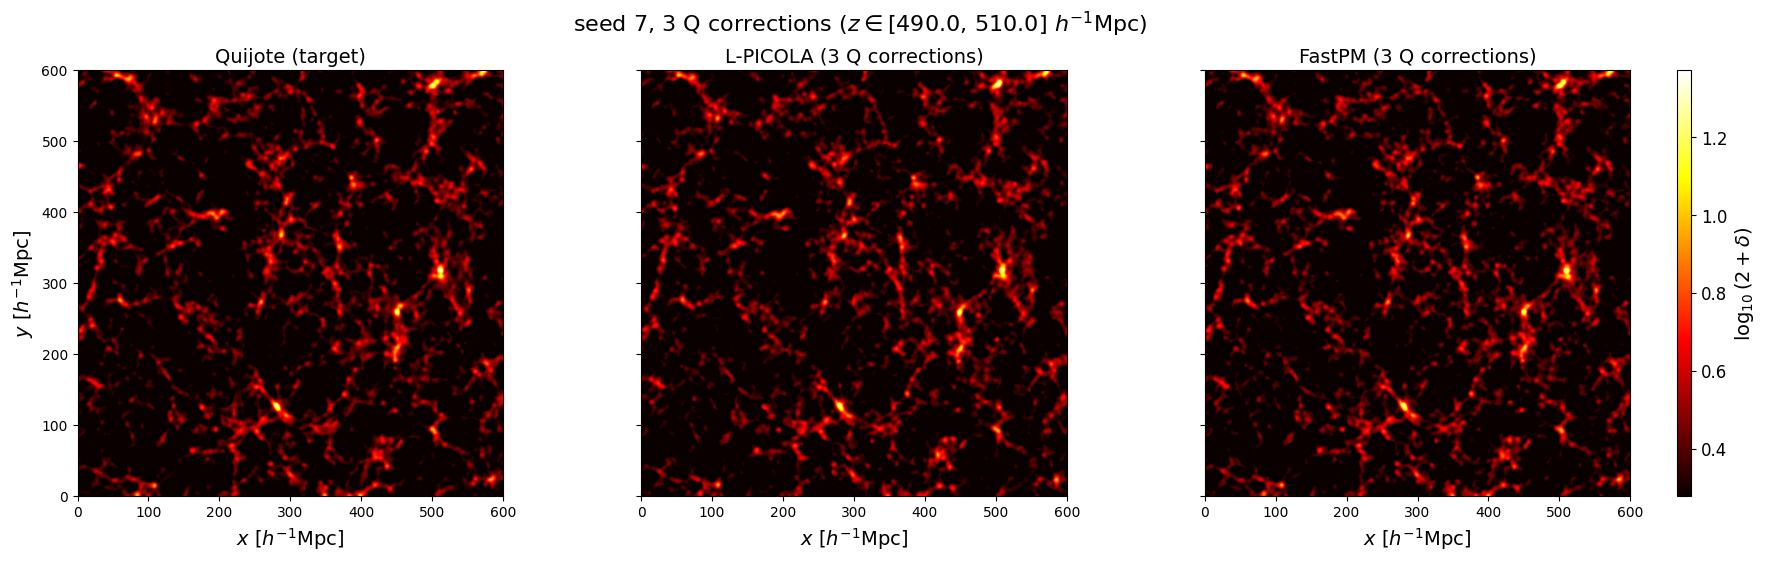

In [13]:
fig, axes = plot_stage_comparison(seed=7, stage=3, log_transform = True)

# After Corr correction with lr

In [15]:
def load_pk_ratio_corr(corr_root, sim, seed, which):
    '''which: "pm" for the uncorrected baseline, or an iteration number (1,2,3,...).
    Reads from Corr_correction/{sim}/seed{seed}/ -- k_pm/pk_pm and
    k_corrected_itN/pk_corrected_itN are the genuine corr-case outputs;
    nb_k/nb_pk are symlinked from quijote_lh via link_baseline.'''
    d = os.path.join(corr_root, sim, "seed%d" % seed)
    if which == "pm":
        k = np.load(os.path.join(d, "k_pm.npy"))
        pk = np.load(os.path.join(d, "pk_pm.npy"))
    else:
        it = int(which)
        k = np.load(os.path.join(d, "k_corrected_it%d.npy" % it))
        pk = np.load(os.path.join(d, "pk_corrected_it%d.npy" % it))
    k_nb = np.load(os.path.join(d, "nb_k.npy"))
    pk_nb = np.load(os.path.join(d, "nb_pk.npy"))
    pk_nb_i = np.interp(k, k_nb, pk_nb)
    return k, pk / pk_nb_i


def plot_pk_ratio_grid_corr(corr_root, sim, lr, n_seeds=50, figroot=None, cmap_name="viridis"):
    '''2x2 grid: PM stage 0 (uncorrected), stage 1, stage 2, stage 3 -- each
    panel is P(k)_stage / P(k)_target per seed, colored by seed index, one
    colorbar spanning the full figure height.'''
    stages = ["pm", "1", "2", "3"]
    titles = ["stage 0 (uncorrected)", "stage 1", "stage 2", "stage 3"]

    fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharex=True, sharey=True,
                              constrained_layout=True)
    axes = axes.ravel()

    cmap = plt.get_cmap(cmap_name)
    norm = plt.Normalize(vmin=0, vmax=n_seeds - 1)

    for ax, stage, title in zip(axes, stages, titles):
        for seed in range(n_seeds):
            k, ratio = load_pk_ratio_corr(corr_root, sim, seed, stage)
            ax.plot(k, ratio, color=cmap(norm(seed)), alpha=0.8, lw=0.8)
        ax.axhline(1.0, color="white", lw=1, ls=":")
        ax.set_xscale("log")
        ax.set_title(title, fontsize=12)
        ax.grid(color="grey", alpha=0.3)

    for ax in axes[2:]:
        ax.set_xlabel(r"$k\ [h/\mathrm{Mpc}]$", fontsize=12)
    for ax in axes[::2]:
        ax.set_ylabel(r"$P(k)/P_\mathrm{target}(k)$", fontsize=12)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes.tolist(), pad=0.02, aspect=40)
    cbar.set_label("seed", fontsize=11)

    fig.suptitle(r"%s corr-case correction, $\mathrm{lr}=%.2f$  ($N=%d$ seeds)"
                 % (sim, lr, n_seeds), fontsize=14)
    if figroot is not None:
        os.makedirs(figroot, exist_ok=True)
        fig.savefig(os.path.join(figroot, "pk_Corr_ratio_grid_%s.pdf" % sim), bbox_inches="tight")
    return fig, axes



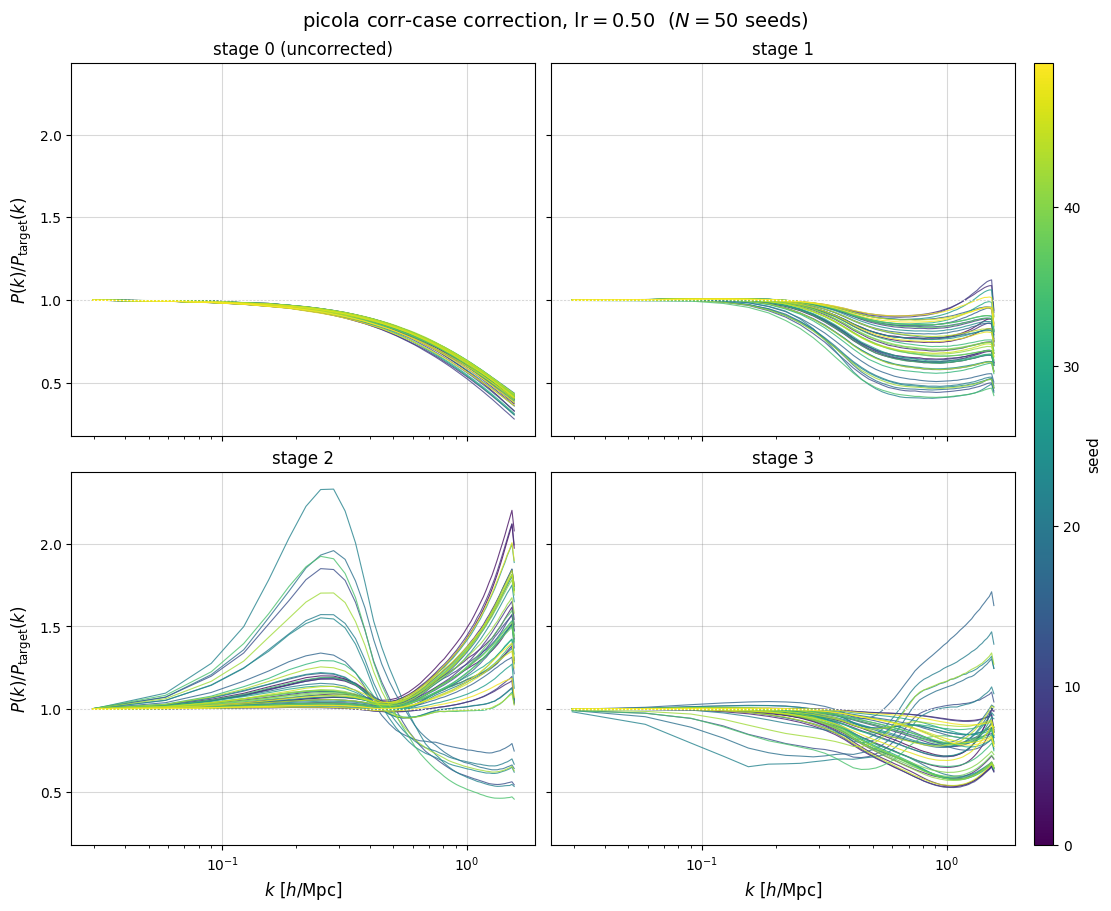

In [16]:
CORR_ROOT = "/work/hdd/bdne/nchartier/Corr_correction"
basedir = "."
fig, axes = plot_pk_ratio_grid_corr(CORR_ROOT, "picola", lr=0.5, figroot=os.path.join(basedir, "PICOLA"))



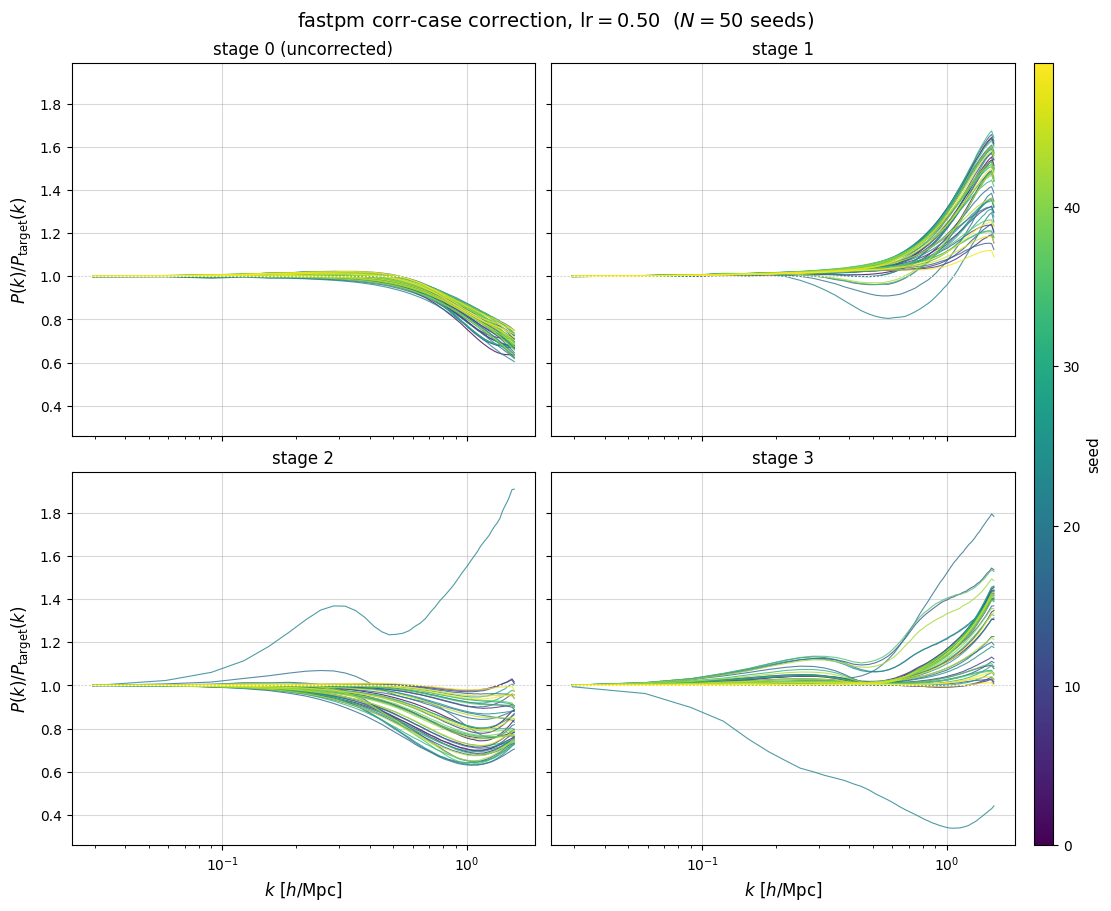

In [17]:
fig, axes = plot_pk_ratio_grid_corr(CORR_ROOT, "fastpm", lr=0.5, figroot=os.path.join(basedir, "FASTPM"))



# After PQMass test

In [18]:
import json
PQM_OUTROOT = "/work/hdd/bdne/nchartier/PQMass_results"
sims, cases, which_bs, grid = ("picola", "fastpm"), ("raw", "octant"), ("1", "3", "pm"), 256

print(f"{'sim':8} {'case':8} {'stage':6} {'#warn':>6}  sample warning")
for sim in sims:
    for case in cases:
        for which_b in which_bs:
            path = os.path.join(PQM_OUTROOT, f"pqm_{case}_{sim}_nb_vs_{which_b}_grid{grid}.json")
            result = json.load(open(path))
            warns = result.get("warnings", [])
            sample = warns[0][:80].replace("\n", " ") if warns else ""
            print(f"{sim:8} {case:8} {which_b:6} {len(warns):6}  {sample}")

sim      case     stage   #warn  sample warning
picola   raw      1         337               Less than half of the Voronoi cells have any samples in them.      
picola   raw      3         355               Less than half of the Voronoi cells have any samples in them.      
picola   raw      pm        315               Less than half of the Voronoi cells have any samples in them.      
picola   octant   1           0  
picola   octant   3           0  
picola   octant   pm          0  
fastpm   raw      1         352               Less than half of the Voronoi cells have any samples in them.      
fastpm   raw      3         342               Less than half of the Voronoi cells have any samples in them.      
fastpm   raw      pm        362               Less than half of the Voronoi cells have any samples in them.      
fastpm   octant   1           0  
fastpm   octant   3           0  
fastpm   octant   pm          0  


In [10]:
from scipy.stats import chi2 as chi2_dist
from pqm import pqm_chi2

def load_nb_fields(quijote_root, seeds, grid=256):
    return [np.load(os.path.join(quijote_root, str(s), "delta_grid%d.npy" % grid)) for s in seeds]

def scramble_field(field, rng):
    '''Random voxel permutation: destroys spatial structure, keeps the exact
    1-point value distribution. A scrambled field should look nothing like an
    unscrambled one to a distance-based test, if the test has any power here.'''
    flat = field.reshape(-1).copy()
    rng.shuffle(flat)
    return flat.reshape(field.shape)

def make_xy(fields_a, fields_b, case):
    if case == "raw":
        return (np.stack([f.reshape(-1) for f in fields_a]),
                np.stack([f.reshape(-1) for f in fields_b]))
    return build_octant_samples(fields_a), build_octant_samples(fields_b)   # case == "octant"

def run_diag(x, y, num_refs, re_tessellation, label):
    chi2_arr = np.asarray(pqm_chi2(x, y, num_refs=num_refs, re_tessellation=re_tessellation))
    pval_arr = chi2_dist.sf(chi2_arr, num_refs - 1)
    print(f"  {label}: chi2_mean={chi2_arr.mean():.2f}  pval_mean={pval_arr.mean():.4g}")
    return chi2_arr, pval_arr

In [11]:
def split_into_octants(field):
    '''Split a (g,g,g) cube into 8 (g/2,g/2,g/2) octants, cut at the midpoint
    of each axis.'''
    g = field.shape[0]
    h = g // 2
    return [field[i:i+h, j:j+h, k:k+h]
            for i in (0, h) for j in (0, h) for k in (0, h)]


def build_octant_samples(fields):
    '''fields: list of (g,g,g) arrays, one per seed.
    Returns (n_seeds*8, (g/2)**3) array of flattened octant samples.'''
    vecs = [oct_.reshape(-1) for f in fields for oct_ in split_into_octants(f)]
    return np.stack(vecs)

In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2 as chi2_dist


def plot_pqm_ood_panels(panels, num_refs=50, sim_label="Picola", figroot=None, fname=None):
    '''
    Reproduce the style of Fig. 3/7 of 2505.13620: one histogram panel per
    case, each showing the chi2_PQM distribution across re-tessellations,
    with the theoretical chi2(dof=num_refs-1) null-hypothesis PDF (black
    line) overlaid identically on every panel.

    panels: ordered list of (label, chi2_array) pairs, e.g.
        [("Quijote LH", chi2_nb_vs_nb),
         (f"{sim_label} stage 0", chi2_pm),
         (f"{sim_label} stage 1", chi2_it1),
         (f"{sim_label} stage 3", chi2_it3)]
    '''
    dof = num_refs - 1
    fig, axes = plt.subplots(ncols=len(panels), figsize=(4.2 * len(panels), 4), sharey=True)
    if len(panels) == 1:
        axes = [axes]

    all_chi2 = np.concatenate([np.asarray(v) for _, v in panels])
    x_max = max(all_chi2.max(), chi2_dist.ppf(0.999, dof)) * 1.05
    x = np.linspace(0, x_max, 500)
    theory_pdf = chi2_dist.pdf(x, dof)
    theory_mean, theory_std = dof, np.sqrt(2 * dof)

    for ax, (label, chi2_arr) in zip(axes, panels):
        chi2_arr = np.asarray(chi2_arr)
        ax.hist(chi2_arr, bins=25, density=True, color="cyan", alpha=0.6, edgecolor="none")
        ax.plot(x, theory_pdf, color="black", lw=1.8)
        ax.set_title(label, fontsize=12)
        ax.set_xlabel(r"$\chi^2_\mathrm{PQM}$", fontsize=11)
        ax.text(0.97, 0.95, r"$%d \pm %.2f$" % (theory_mean, theory_std),
                transform=ax.transAxes, ha="right", va="top", color="black", fontsize=9)
        ax.text(0.97, 0.88, r"$%.2f \pm %.2f$" % (chi2_arr.mean(), chi2_arr.std()),
                transform=ax.transAxes, ha="right", va="top", color="darkcyan", fontsize=9)
        ax.grid(color="grey", alpha=0.3)

    axes[0].set_ylabel("Frequency (density)", fontsize=11)
    fig.suptitle(r"PQMass field-level OOD test — %s" % sim_label, fontsize=14)
    plt.tight_layout()
    if figroot is not None and fname is not None:
        os.makedirs(figroot, exist_ok=True)
        plt.savefig(os.path.join(figroot, fname), bbox_inches="tight")
    return fig, axes


# Trying PQMass

## 2d tests

## 3d tests

In [10]:
from pqm import pqm_chi2

QUIJOTE_ROOT = "/work/hdd/bdne/nchartier/quijote_lh"
CORR_ROOT = "/work/hdd/bdne/nchartier/Q_correction"

def load_quijote_delta(seed, grid):
    return np.load(os.path.join(QUIJOTE_ROOT, str(seed), "delta_grid%d.npy" % grid))

def load_saved_field(sim, seed, which, grid):
    d = os.path.join(CORR_ROOT, sim, "seed%d" % seed)
    if which == "pm":
        fname = "delta_pm_grid%d.npy" % grid
    else:
        fname = "delta_corrected_%s_grid%d.npy" % (which, grid)
    return np.load(os.path.join(d, fname))

def downsample_3d(field_3d, factor):
    nz, ny, nx = field_3d.shape
    nz_trim = (nz // factor) * factor
    ny_trim = (ny // factor) * factor
    nx_trim = (nx // factor) * factor
    trimmed = field_3d[:nz_trim, :ny_trim, :nx_trim]
    return trimmed.reshape(nz_trim // factor, factor,
                            ny_trim // factor, factor,
                            nx_trim // factor, factor).mean(axis=(1, 3, 5))

def quick_hub_check(x, y, num_refs=25, seed=0):
    from pqm.utils import _sample_reference_indices_numpy, _compute_counts_numpy
    Nx = num_refs // 2
    Ny = num_refs - Nx
    np.random.seed(seed)
    refs, x_rem, y_rem = _sample_reference_indices_numpy(Nx, Ny, 0, x.copy(), y.copy())
    counts_x, counts_y = _compute_counts_numpy(x_rem, y_rem, refs, num_refs, kernel="euclidean")
    n_filled = ((counts_x > 0) | (counts_y > 0)).sum()
    top_bin_frac = max(counts_x.max(), counts_y.max()) / (counts_x.sum() + counts_y.sum())
    print(f"  filled bins: {n_filled}/{num_refs}, top bin holds {top_bin_frac:.1%} of samples")
    return counts_x, counts_y

grid = 512
downsample_factor = 256  # -> 2^3 = 8 dims, our validated safe starting point

quijote_seeds = range(0, 101)  # adjust to whatever range you've actually confirmed complete

def build_x(sim, stage, factor):
    which = "pm" if stage == 0 else "it%d" % stage
    fields = []
    for seed in range(0, 50):
        delta_3d = load_saved_field(sim, seed, which, grid)
        fields.append(downsample_3d(delta_3d, factor).ravel())
    return np.stack(fields)

def build_y(seeds, factor):
    fields = []
    for seed in seeds:
        delta_3d = load_quijote_delta(seed, grid)
        fields.append(downsample_3d(delta_3d, factor).ravel())
    return np.stack(fields)

## PQMass field-level test — 3D, downsampled

**summary with the help of a LLM**

**What this tests:** whether the distribution of L-PICOLA/FastPM density fields
(50 realizations, drawn from the Latin Hypercube) is statistically distinguishable
from the distribution of Quijote (target) density fields. 


**Why downsample:** PQMass needs a Voronoi tessellation of the sample space to
work reliably, and with only `~50`-`100` realizations per side, the raw field
(`256³`/`512³` ≈ millions of dimensions) is far too high-dimensional for that —
we hit this directly earlier as a `ValueError`/warning from PQMass itself
("Only one Voronoi cell has samples")
`downsample_3d` block-averages the field down to a much coarser grid
(`factor=256` on a `grid=512` field → `2×2×2=8` dimensions) before flattening,
trading spatial resolution for statistical reliability.

**`quick_hub_check` output** (`filled bins: X/num_refs, top bin holds Y%`):
a cheap, single-draw diagnostic before running the full (expensive,
`re_tessellation=1000`) test. `num_refs` reference points are drawn from `x`
and `y` combined; every remaining sample is assigned to its nearest reference,
and we check how evenly those assignments spread across bins. Close to
`num_refs` filled bins and a low top-bin percentage means the space is well
partitioned; few filled bins or one dominant bin means the result would be
unreliable or would error outright.

**The final `pqm_chi2` output** (`mean`, `std` printed): `re_tessellation=1000`
repeats the test with different random reference points each time, giving a
distribution of `χ²_PQM` values. Under the null hypothesis (same underlying
distribution) this should follow a `χ²` distribution with `dof = num_refs - 1`
— mean `≈ dof`, std `≈ √(2·dof)`. A mean well above `dof` (with a std in the
right ballpark, not anomalously small) indicates the two sets are
distinguishable — i.e. picola/fastpm's field distribution measurably differs
from Quijote's at whatever spatial scale this downsampling still resolves.

In [33]:
x = build_x("picola", stage=0, factor=downsample_factor)
y = build_y(quijote_seeds, factor=downsample_factor)
print("x shape:", x.shape, " y shape:", y.shape)

x shape: (50, 8)  y shape: (101, 8)


In [34]:
quick_hub_check(x, y, num_refs=25)

  filled bins: 24/25, top bin holds 10.3% of samples


(array([2, 2, 0, 0, 0, 0, 1, 4, 0, 0, 3, 0, 2, 2, 3, 5, 1, 1, 2, 0, 1, 1,
        4, 1, 3]),
 array([ 4,  9,  4,  4,  2,  2,  2, 12,  1,  1,  7,  2,  1,  1,  3, 13,  1,
         1,  1,  0,  2,  0,  7,  0,  8]))

**PQMASS errors and warning notes**

- UserWarning (from pqm.pqm._pqm_test, pqm/pqm.py:172-175):Less than half of the Voronoi cells have any samples in them.
Possibly due to a small number of samples or a pathological
distribution. Result may be unreliable. If possible, increase the
number of x_samples and y_samples. [Context: first field-level test, 2D slices (~1444 dims after downsampling), num_refs=20, N_x=N_y=50 (picola vs. Quijote).]
- ValueError (from pqm.pqm._pqm_test, pqm/pqm.py:163-171):Only one Voronoi cell has samples, so chi^2 cannot 
be computed. This is likely due to a small number 
of samples or a pathological distribution. If possible, 
increase the number of x_samples and y_samples. [Context: hit this one twice — Quijote null test with a 25-vs-25 split of the same 50 realizations at num_refs=10, and again on the independent 50-vs-50 Quijote null test (original 0-49 vs. new 51-100) at num_refs=25. Both are field-level (2D slice) tests.]

## PQMASS tests before jobs

In [20]:
from scipy.stats import chi2 as chi2_dist

def run_pqm(x, y, num_refs=50, re_tessellation=1000, **kwargs):
    chi2_list = pqm_chi2(x, y, num_refs=num_refs, re_tessellation=re_tessellation, **kwargs)
    chi2_arr = np.asarray(chi2_list)
    pval_arr = chi2_dist.sf(chi2_arr, num_refs - 1)
    return chi2_arr, pval_arr


def pqmass_raw_test(fields_a, fields_b, num_refs=50, re_tessellation=1000, **pqm_kwargs):
    x = np.stack([f.reshape(-1) for f in fields_a])
    y = np.stack([f.reshape(-1) for f in fields_b])
    print(f"x: {x.shape}, y: {y.shape}, num_refs={num_refs}")
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always")
        try:
            chi2_arr, pval_arr = run_pqm(x, y, num_refs=num_refs,
                                          re_tessellation=re_tessellation, **pqm_kwargs)
            result = dict(chi2_mean=float(chi2_arr.mean()), chi2_std=float(chi2_arr.std()),
                          pval_mean=float(pval_arr.mean()), pval_std=float(pval_arr.std()),
                          chi2=chi2_arr, pval=pval_arr, failed=False)
        except ValueError as e:
            print(f"  FAILED: {e}")
            result = dict(failed=True, error=str(e))
        for warning in w:
            print(f"  warning: {warning.message}")
    return result


def sweep_num_refs_raw(fields_a, fields_b, num_refs_list=(5, 10, 20, 50), **kwargs):
    '''Quick cell-test loop: try several num_refs on the raw (undownsampled) fields
    to see which avoid the hub failure. Lower num_refs = fewer, larger Voronoi
    regions = less likely for a region to end up empty.'''
    results = {}
    for nr in num_refs_list:
        print(f"--- num_refs={nr} ---")
        results[nr] = pqmass_raw_test(fields_a, fields_b, num_refs=nr, **kwargs)
    return results


def split_into_octants(field):
    '''Split a (g,g,g) cube into 8 (g/2,g/2,g/2) octants, cut at the midpoint
    of each axis.'''
    g = field.shape[0]
    h = g // 2
    return [field[i:i+h, j:j+h, k:k+h]
            for i in (0, h) for j in (0, h) for k in (0, h)]


def build_octant_samples(fields):
    '''fields: list of (g,g,g) arrays, one per seed.
    Returns (n_seeds*8, (g/2)**3) array of flattened octant samples.'''
    vecs = [oct_.reshape(-1) for f in fields for oct_ in split_into_octants(f)]
    return np.stack(vecs)




def pqmass_octant_test(fields_a, fields_b, num_refs=50, re_tessellation=1000, **pqm_kwargs):
    x = build_octant_samples(fields_a)
    y = build_octant_samples(fields_b)
    print(f"x: {x.shape}, y: {y.shape}, num_refs={num_refs}")
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always")
        try:
            chi2_arr, pval_arr = run_pqm(x, y, num_refs=num_refs,
                                          re_tessellation=re_tessellation, **pqm_kwargs)
            result = dict(chi2_mean=float(chi2_arr.mean()), chi2_std=float(chi2_arr.std()),
                          pval_mean=float(pval_arr.mean()), pval_std=float(pval_arr.std()),
                          chi2=chi2_arr, pval=pval_arr, failed=False)
        except ValueError as e:
            print(f"  FAILED: {e}")
            result = dict(failed=True, error=str(e))
        for warning in w:
            print(f"  warning: {warning.message}")
    return result


In [17]:
quick_seeds = range(5)   # just 5 seeds for a fast sanity pass
sim = "picola" # or fastpm
fields_nb_quick = [load_saved_field(sim, s, "nb", grid=256) for s in quick_seeds]
fields_pm_quick = [load_saved_field(sim, s, "pm", grid=256) for s in quick_seeds]

import warnings


In [18]:
print("raw case, quick subset:")
_ = pqmass_raw_test(fields_nb_quick, fields_pm_quick, num_refs=3, re_tessellation=50)

raw case, quick subset:
x: (5, 16777216), y: (5, 16777216), num_refs=3


 12%|█▏        | 6/50 [00:04<00:33,  1.33it/s]

  FAILED: Cannot sample more references from x_samples than available


In [21]:
print("octant case, quick subset:")
_ = pqmass_octant_test(fields_nb_quick, fields_pm_quick, num_refs=3, re_tessellation=50)

octant case, quick subset:
x: (40, 2097152), y: (40, 2097152), num_refs=3


100%|██████████| 50/50 [00:35<00:00,  1.41it/s]
